In [26]:
pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 1.0/101.7 MB 6.3 MB/s eta 0:00:16
    --------------------------------------- 1.8/101.7 MB 4.6 MB/s eta 0:00:22
   - -------------------------------------- 2.6/101.7 MB 4.4 MB/s eta 0:00:23
   - -------------------------------------- 3.4/101.7 MB 3.9 MB/s eta 0:00:25
   - -------------------------------------- 4.5/101.7 MB 4.1 MB/s eta 0:00:24
   -- ------------------------------------- 5.2/101.7 MB 4.1 MB/s eta 0:00:24
   -- ------------------------------------- 6.0/101.7 MB 4.1 MB/s eta 0:00:24
   -- ------------------------------------- 6.8/101.7 MB 4.1 MB/s eta 0:00:24
   --- ------------------------------------ 7.9/101.7 MB 4.0 MB/s eta 0:00:24
   --- ------------------------------------ 8.7/101.7 MB 4.0 MB/s eta 0:00:24
   --- ------------------------------------ 9.4/101.7 MB 4.0 MB/s eta 0:00:24
   ---- ----------------------------------- 10.2/101.7 MB 4.0 MB/s eta 

In [1]:
import pandas as pd

df = pd.read_csv(
    "../data/processed/featured_data.csv"
)

In [12]:
#selecting only relevant features for modeling
features = [

    'Temperature(F)',

    'Humidity(%)',

    'Visibility(mi)',

    'Wind_Speed(mph)',

    'hour',

    'day_of_week',

    'month',

    'duration',

    'is_rush_hour',

    'is_night'
]

X = df[features]

y = df['Severity']-1

In [13]:
print(sorted(y.unique()))

[0, 1, 2, 3]


In [14]:
#train test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    stratify=y,

    random_state=42
)

In [15]:
#scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train
)

X_test = scaler.transform(
    X_test
)

In [16]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)


X_train shape: (80000, 10)
y_train shape: (80000,)


In [17]:
#SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(

    X_train,

    y_train
)

In [18]:
#Logistic Regression

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000
)

lr.fit(
    X_train,
    y_train
)

LogisticRegression(max_iter=1000)

In [19]:
#Random forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

RandomForestClassifier(random_state=42)

In [20]:
#XGBoost
from xgboost import XGBClassifier

xgb = XGBClassifier(

    objective='multi:softprob',

    num_class=4,

    eval_metric='mlogloss'
)

xgb.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None, num_class=4, ...)

In [21]:
pred = xgb.predict(X_test)

pred = pred + 1

y_test_original = y_test + 1

1 → Minor Injury 
2 → Moderate Injury
3 → Serious Injury
4 → Fatal

In [48]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
lr.score(X_test, y_test)

0.2287

In [50]:
rf.score(X_test, y_test)

0.75345

In [51]:
xgb.score(X_test, y_test)

0.7771

In [52]:
from sklearn.metrics import classification_report

lr_pred = lr.predict(X_test)

print(classification_report(
    y_test + 1,
    lr_pred + 1
))

              precision    recall  f1-score   support

           1       0.02      0.70      0.04       163
           2       0.88      0.17      0.28     15937
           3       0.26      0.46      0.33      3367
           4       0.04      0.37      0.08       533

    accuracy                           0.23     20000
   macro avg       0.30      0.43      0.18     20000
weighted avg       0.74      0.23      0.28     20000



In [53]:
rf_pred = rf.predict(X_test)

print(classification_report(
    y_test + 1,
    rf_pred + 1
))

              precision    recall  f1-score   support

           1       0.14      0.14      0.14       163
           2       0.83      0.88      0.85     15937
           3       0.37      0.31      0.34      3367
           4       0.14      0.07      0.10       533

    accuracy                           0.75     20000
   macro avg       0.37      0.35      0.36     20000
weighted avg       0.73      0.75      0.74     20000



In [54]:
xgb_pred = xgb.predict(X_test)

print(classification_report(
    y_test + 1,
    xgb_pred + 1
))

              precision    recall  f1-score   support

           1       0.12      0.25      0.17       163
           2       0.83      0.91      0.87     15937
           3       0.45      0.27      0.34      3367
           4       0.24      0.06      0.09       533

    accuracy                           0.78     20000
   macro avg       0.41      0.37      0.37     20000
weighted avg       0.75      0.78      0.75     20000



In [55]:
from sklearn.metrics import accuracy_score

print("Logistic Regression:",
      accuracy_score(y_test, lr_pred))

print("Random Forest:",
      accuracy_score(y_test, rf_pred))

print("XGBoost:",
      accuracy_score(y_test, xgb_pred))

Logistic Regression: 0.2287
Random Forest: 0.75345
XGBoost: 0.7771


In [56]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, xgb_pred)

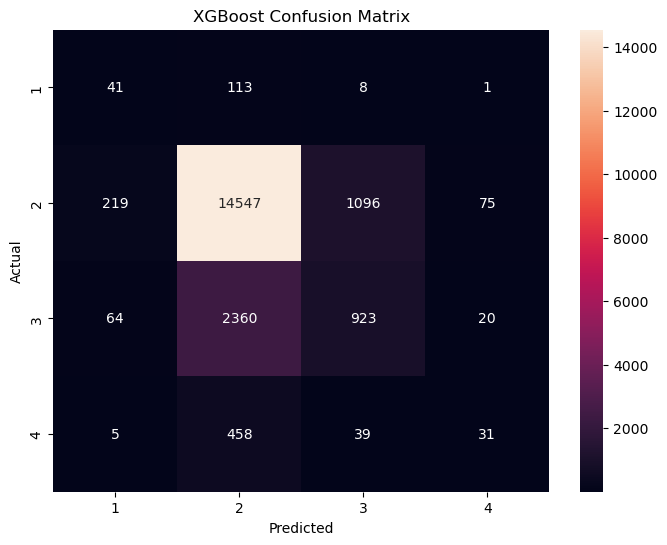

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=[1,2,3,4],
    yticklabels=[1,2,3,4]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("XGBoost Confusion Matrix")

plt.show()

In [58]:
importance = xgb.feature_importances_

feature_names = X.columns

In [59]:
import pandas as pd

imp_df = pd.DataFrame({

    'Feature': feature_names,

    'Importance': importance

})

imp_df = imp_df.sort_values(
    by='Importance',
    ascending=False
)

imp_df.head(10)

,Feature,Importance
7,duration,0.243484
6,month,0.236923
5,day_of_week,0.103820
3,Wind_Speed(mph),0.097821
4,hour,0.079006
9,is_night,0.053203
2,Visibility(mi),0.049400
8,is_rush_hour,0.048041
0,Temperature(F),0.047202
1,Humidity(%),0.041101


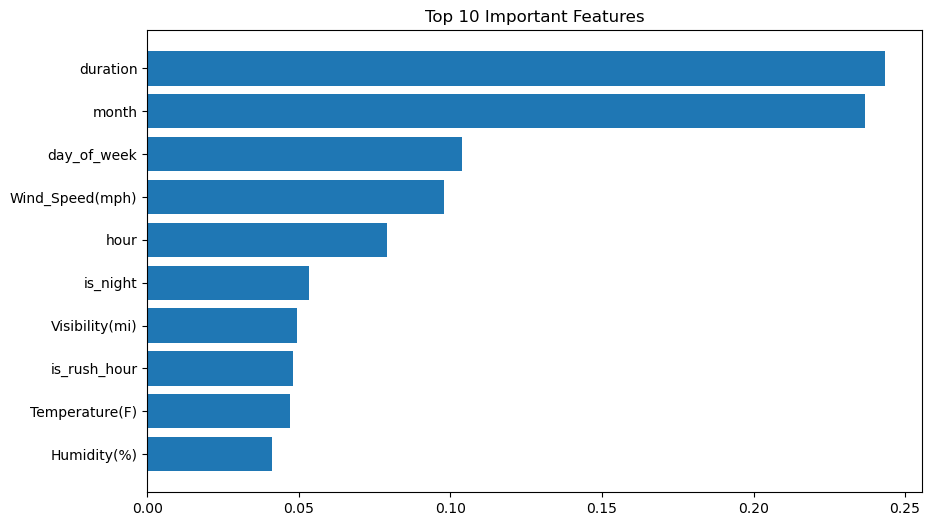

In [60]:
plt.figure(figsize=(10,6))

plt.barh(
    imp_df['Feature'][:10],
    imp_df['Importance'][:10]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Important Features")

plt.show()

In [67]:
import pandas as pd

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

importance_df

,Feature,Importance
7,duration,0.243484
6,month,0.236923
5,day_of_week,0.103820
3,Wind_Speed(mph),0.097821
4,hour,0.079006
9,is_night,0.053203
2,Visibility(mi),0.049400
8,is_rush_hour,0.048041
0,Temperature(F),0.047202
1,Humidity(%),0.041101


In [68]:
import joblib

In [69]:
joblib.dump(xgb, "../models/xgboost.pkl")
joblib.dump(scaler, "../models/scaler.pkl")
joblib.dump(features, "../models/features.pkl")
joblib.dump(importance_df, "../models/feature_importance.pkl")

['../models/feature_importance.pkl']